--- Data Head ---
      brand    model  year fuel_type transmission  km_driven owner_type  \
0     Honda    Amaze  2025    Petrol       Manual      11067      Third   
1      Tata   Altroz  2025    Diesel    Automatic       9114      First   
2      Tata    Punch  2021       CNG    Automatic      75049     Second   
3    Maruti   Brezza  2021    Petrol       Manual      74402     Second   
4  Mahindra  Scorpio  2022    Diesel    Automatic      38984     Second   

     city  mileage  engine_cc  ...  estimated_final_price  days_to_sell  \
0   Delhi       15       1199  ...                 739003            20   
1   Delhi       15       1199  ...                 579222            21   
2   Delhi       20       1199  ...                 466743            36   
3  Mumbai       19       1462  ...                 506724            34   
4   Delhi       12       2184  ...                 701332            36   

   bargain_percent  car_age  depreciation_amount  resale_value_percent  \
0     

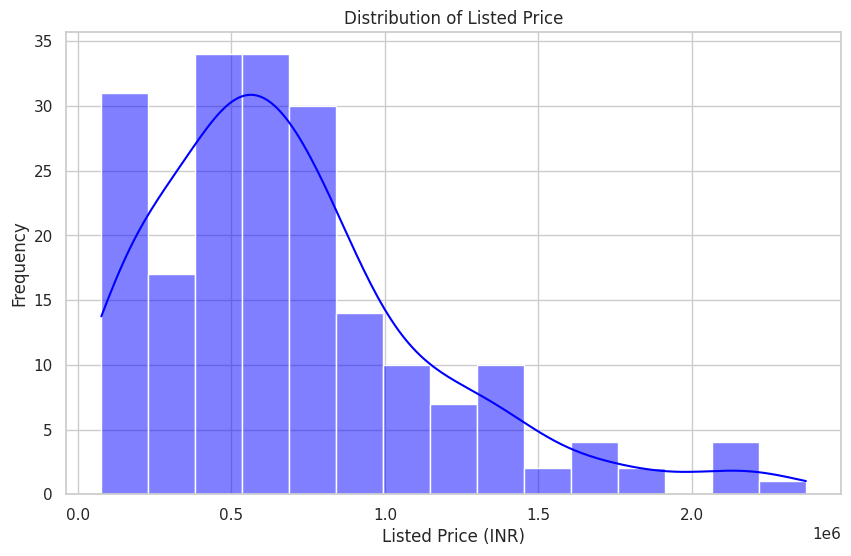

/tmp/ipykernel_14367/1120300737.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='viridis')


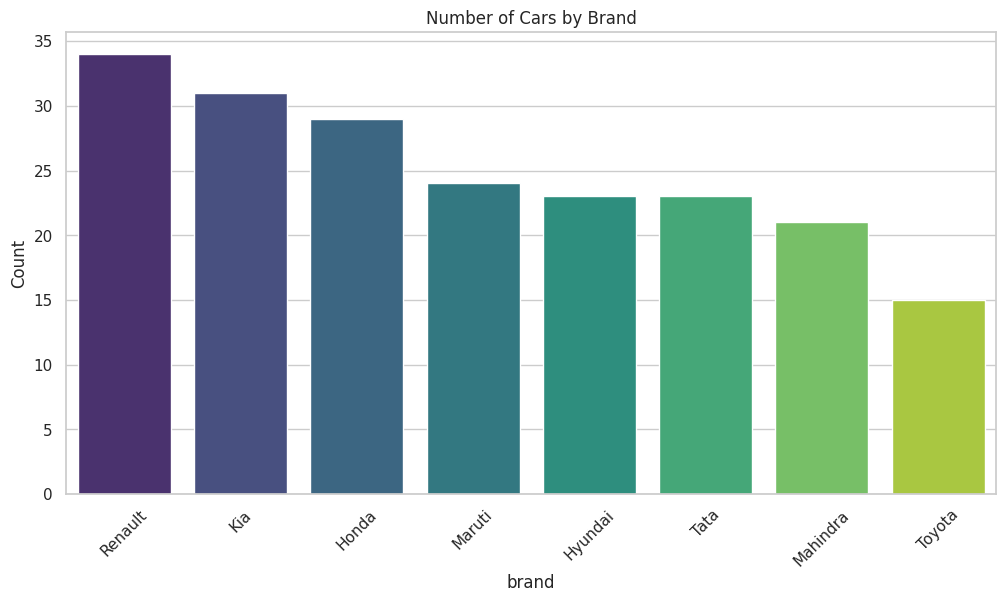

/tmp/ipykernel_14367/1120300737.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fuel_type', palette='Set2', order=df['fuel_type'].value_counts().index)


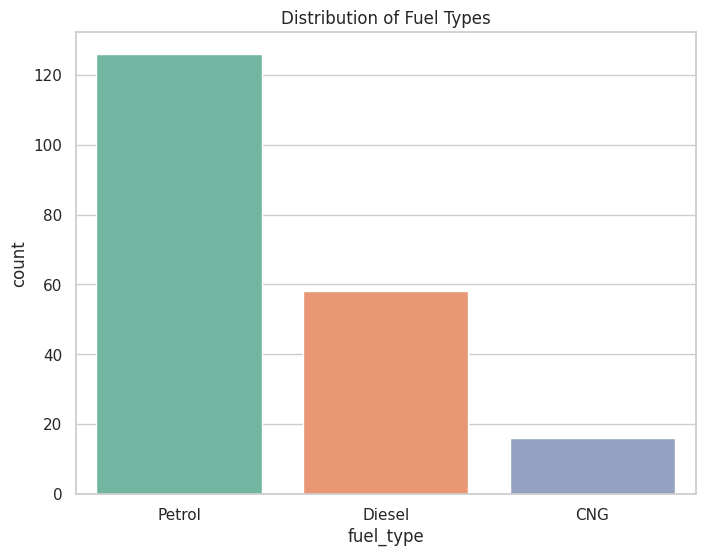

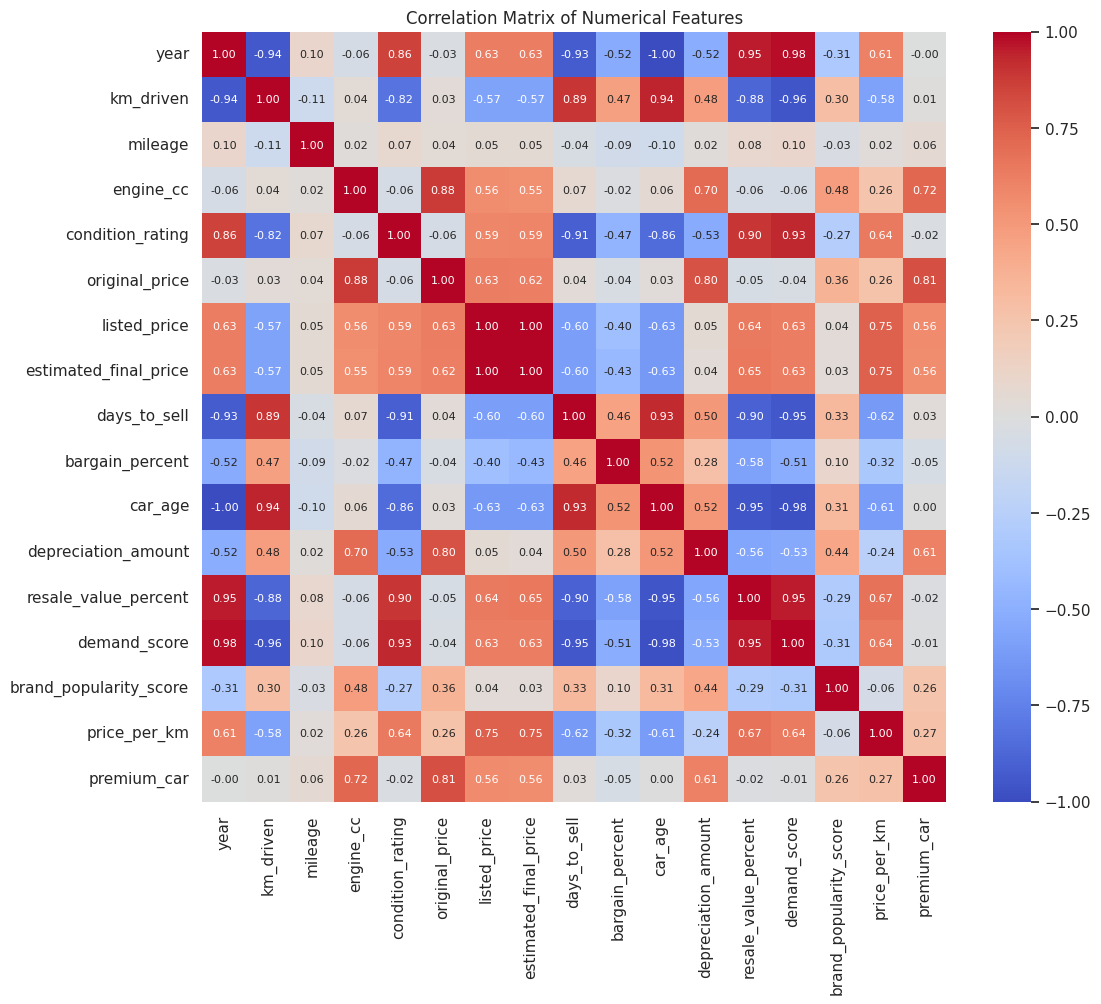

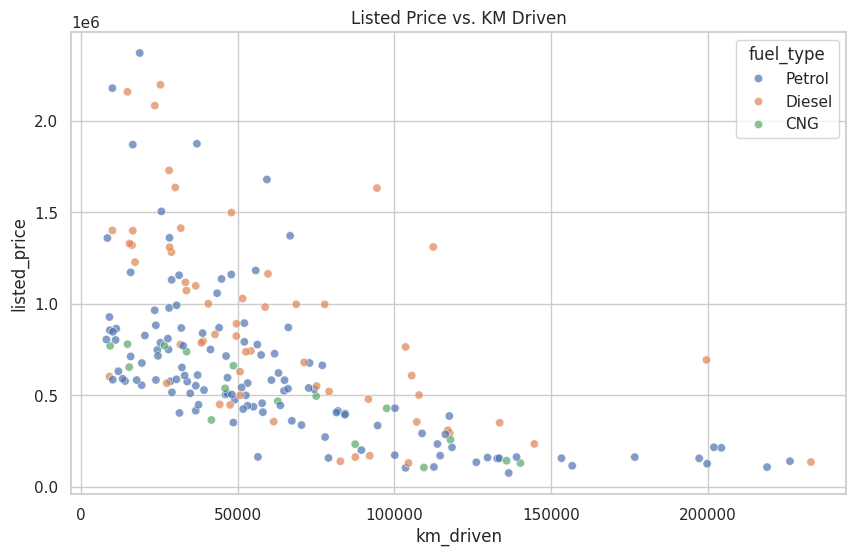

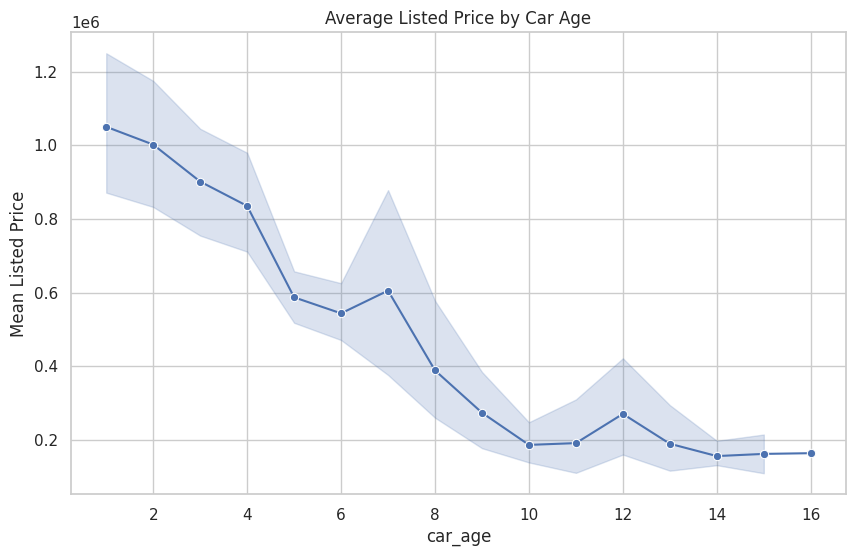


--- Average Price by Transmission ---
transmission
Automatic    680093.336364
Manual       711115.588889
Name: listed_price, dtype: float64

--- Average Price by Fuel Type ---
fuel_type
CNG       472136.937500
Diesel    887004.879310
Petrol    633414.253968
Name: listed_price, dtype: float64

--- Top 5 Most Frequent Models ---
model
Triber    13
Seltos    13
Kiger     12
Jazz      11
i20       10
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'final_indian_used_car_market_dataset.csv'
df = pd.read_csv(file_path)

print("--- Data Head ---")
print(df.head())

print("\n--- Data Info (Columns & Types) ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

sns.set(style="whitegrid")


plt.figure(figsize=(10, 6))
sns.histplot(df['listed_price'], kde=True, color='blue')
plt.title('Distribution of Listed Price')
plt.xlabel('Listed Price (INR)')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(12, 6))
brand_counts = df['brand'].value_counts()
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='viridis')
plt.title('Number of Cars by Brand')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='fuel_type', palette='Set2', order=df['fuel_type'].value_counts().index)
plt.title('Distribution of Fuel Types')
plt.show()


plt.figure(figsize=(12, 10))
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='km_driven', y='listed_price', hue='fuel_type', alpha=0.7)
plt.title('Listed Price vs. KM Driven')
plt.show()


plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='car_age', y='listed_price', marker='o')
plt.title('Average Listed Price by Car Age')
plt.ylabel('Mean Listed Price')
plt.show()


print("\n--- Average Price by Transmission ---")
print(df.groupby('transmission')['listed_price'].mean())

print("\n--- Average Price by Fuel Type ---")
print(df.groupby('fuel_type')['listed_price'].mean())

print("\n--- Top 5 Most Frequent Models ---")
print(df['model'].value_counts().head(5))